In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%cd ..

/Users/admin/repos/geneforge


In [ ]:
import pandas as pd
from geneforge.gene import fetch_ensembl_ids
import random
from geneforge.circuits.utils import generate_feed_forward_loop
from geneforge.circuits.utils import visualize_circuit
from geneforge.gene import fetch_ensembl_ids


human_tfs = pd.read_csv("data/comp_lib_of_human_tfs/tfs_in_the_human_tfome.csv").iloc[:,0].tolist()
human_tf_ens_ids = fetch_ensembl_ids(human_tfs)
print(len(human_tfs))

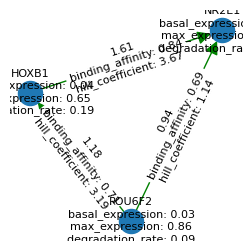

In [13]:
circuit_gene_symbols = random.sample(human_tfs, 3)
circuit_ensembl_ids = fetch_ensembl_ids(circuit_gene_symbols)
ffl = generate_feed_forward_loop(*circuit_gene_symbols)
visualize_circuit(ffl, figsize=(3,3))

In [ ]:
from geneforge.gene import fetch_mean_expression

tissue="lung"
cell_type="mucus secreting cell"
mean_expression = fetch_mean_expression(cell_type, tissue)
mean_expression

In [14]:
circuit_initial_conditions = {k: mean_expression[ensembl_id] for k, ensembl_id in circuit_ensembl_ids.items()}
circuit_initial_conditions

{'POU6F2': 0.00046403712, 'HOXB1': 0.00046403712, 'NR2E1': 0.0}

(100, 4)


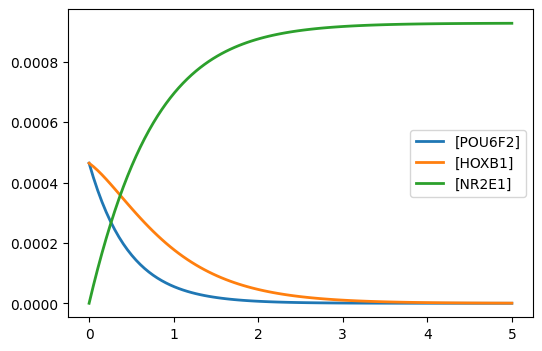

In [15]:
from geneforge.circuits.utils import circuit_to_sbml
import tellurium as te

sbml_model = circuit_to_sbml(ffl, initial_conditions=circuit_initial_conditions)
sbml_str = sbml_model.toSBML()
rr = te.loads(sbml_str)
result = rr.simulate(0, 5, 100)  # Simulate from time 0 to 5 with 100 points
print(result.shape) # timesteps, gene1, gene2, gene2)
rr.plot(result)

In [17]:
circuit_initial_conditions

{'POU6F2': 0.00046403712, 'HOXB1': 0.00046403712, 'NR2E1': 0.0}

In [23]:
from geneforge.gene import get_string_interactions
import numpy as np

def simulate_degradation_rates(num_genes, mean_rate=0.1, std_dev=0.05):
    return np.abs(np.random.normal(mean_rate, std_dev, num_genes))

genes = ['EGFR', 'HRAS', 'RAF1', 'MAP2K1', 'MAPK1', 'DUSP1']
interactions = get_string_interactions(genes)
deg_rates = simulate_degradation_rates(len(genes))